In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mne

sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(sample_data_raw_file)
raw.crop(0, 60).pick(picks=["mag"]).load_data();
raw.del_proj("all");

In [ ]:
class utils:

    @staticmethod
    def plot_filtered(before, after, tmin, tmax):
        plt.plot(before.times, before.get_data()[0], label="original")
        plt.plot(after.times, after.get_data()[0], label="after filtering")
        plt.xlim(tmin, tmax)
        plt.xlabel("Time [s]")
        plt.ylabel("Amplitude [a.u.]")
        plt.legend()
        plt.show()

    @staticmethod
    def make_oscillation(dur, freq, t_start, t_stop, sfreq=500, plot=False):

        n_samples = int(sfreq * dur)
        t = np.linspace(0, dur, n_samples)
        signal = np.zeros(n_samples)

        burst_mask = (t >= t_start) & (t <= t_stop)
        signal[burst_mask] = np.sin(2 * np.pi * freq * t[burst_mask])

        info = mne.create_info( ch_names=['ch1'], sfreq=sfreq, ch_types=['eeg'])
        raw = mne.io.RawArray(signal[np.newaxis, :], info)

        if plot:
            plt.plot(raw.times, raw.get_data()[0])
            plt.xlabel("Time [s]")
            plt.ylabel(r"Amplitude $\mu$V")
            plt.show()
        
        return raw
    
    @staticmethod
    def make_impulse(dur, t_impulse, width, amplitude=1.0, sfreq=500, plot=False):
        """
        Create an impulse (spike) signal.
        
        Parameters
        ----------
        dur : float
            Duration of signal in seconds
        t_impulse : float
            Time point of impulse in seconds
        amplitude : float
            Amplitude of the impulse (default: 1.0)
        sfreq : int
            Sampling frequency in Hz (default: 500)
        plot : bool
            Whether to plot the signal (default: False)
        
        Returns
        -------
        raw : mne.io.RawArray
            MNE Raw object containing the impulse signal
        """
        n_samples = int(sfreq * dur)
        signal = np.zeros(n_samples)
        
        # Find the sample index closest to t_impulse
        impulse_start = int(t_impulse * sfreq)
        impulse_stop = int((t_impulse+width) * sfreq)
        signal[impulse_start:impulse_stop] = amplitude
        
        info = mne.create_info(ch_names=['ch1'], sfreq=sfreq, ch_types=['eeg'])
        raw = mne.io.RawArray(signal[np.newaxis, :], info)
        
        if plot:
            plt.plot(raw.times, raw.get_data()[0])
            plt.xlabel("Time [s]")
            plt.ylabel(r"Amplitude $\mu$V")
            plt.title("Impulse Signal")
            plt.show()
        
        return raw
    
    @staticmethod
    def make_step(dur, t_step, amplitude=1.0, sfreq=500, plot=False):
        """
        Create a step function signal.
        
        Parameters
        ----------
        dur : float
            Duration of signal in seconds
        t_step : float
            Time point of step transition in seconds
        amplitude : float
            Amplitude after the step (default: 1.0)
        sfreq : int
            Sampling frequency in Hz (default: 500)
        plot : bool
            Whether to plot the signal (default: False)
        
        Returns
        -------
        raw : mne.io.RawArray
            MNE Raw object containing the step signal
        """
        n_samples = int(sfreq * dur)
        t = np.linspace(0, dur, n_samples)
        signal = np.zeros(n_samples)
        
        # Step occurs at t_step
        signal[t >= t_step] = amplitude
        
        info = mne.create_info(ch_names=['ch1'], sfreq=sfreq, ch_types=['eeg'])
        raw = mne.io.RawArray(signal[np.newaxis, :], info)
        
        if plot:
            plt.plot(raw.times, raw.get_data()[0])
            plt.xlabel("Time [s]")
            plt.ylabel(r"Amplitude $\mu$V")
            plt.title("Step Function")
            plt.show()
        
        return raw

## Removing Drift and Powerline Artifacts

| Code | Description |
| --- | --- |
| `raw.plot(duration=10)` | Plot a `10` second segment of the data stored in `raw` |
| `raw2 = raw.copy()` | Create a new copy of the `raw` object names `raw2` |
| `raw.filter(l_freq=1, h_freq=None)` | Apply a 1 Hz highpass filter to `raw` |
| `raw.filter(l_freq=None, h_freq=40)` | Apply a 40 Hz lowpass filter to `raw` |
| `raw.filter(l_freq=1, h_freq=40)` | Apply a 1 Hz to 40 Hz bandpass filter to `raw` |
| `raw.notch_filter(freqs=(50, 100))` | Apply a notch filter at `50` and `100` Hx to `raw` |
| `raw.notch_filter(freqs=(50, 100), notch_widths=2)` | Set the width of the filter's notches to `2` Hz |
| `spectrum = raw.compute_psd()` | Compute the power spectral density (PSD) of `raw`|
| `spectrum.plot(average=True)` | Plot the PSD, averaged across all sensors |
| `spectrum.plot(average=True, xscale="log")` | Plot the average PSD with a logarithmically scaled x-axis |



Run the cell below to plot one minute of raw MEG data. Several channels show **drifts** - slow fluctuations in the measured signals that can be caused for example by changes in temperature or environmental magnetic fields. These drift artifacts can be removed using a **highpass** filter.

In [ ]:
raw.plot(duration=60);

**Example**: Create a new copy of `raw` called `raw_hp`. Then, apply a `0.1` Hz highpass filter to `raw_hp` and plot the filtered data. As you can see, the filter did not remove the drifts completely.

In [ ]:
raw_hp = raw.copy()
raw_hp.filter(l_freq=0.1, h_freq=None)
raw_hp.plot(duration=60);

**Exercise**: Create a new copy of `raw` called `raw_hp`. Then, apply a `1` Hz highpass filter to `raw_hp` and plot the filtered data.

In [ ]:
raw_hp = raw.copy()
raw_hp.filter(l_freq=1, h_freq=None)
raw_hp.plot(duration=60);

**Exercise**: Create a new copy of `raw` called `raw_hp`. Then, apply a `0.3` Hz highpass filter to `raw_hp` and plot the filtered data.

In [ ]:
raw_hp = raw.copy()
raw_hp.filter(l_freq=0.3, h_freq=None)
raw_hp.plot(duration=60);

Another important technique to assess artifacts in EEG/MEG signals is the power spectral density (PSD). The PSD describes how the power of a signal is distributed across different frequencies. It essentially tells you which frequencies are present in your signal and how strong they are. Execute the cell below to compiute and plot the PSD of `raw` - you'll see distinct spikes at 60 Hz and its multiples (i.e. 120, 180 and 240 Hz). These are artifacts caused by the alternating current of the power line which operates at 60 Hz (in the US, in Europe it would be 50 Hz). These artifacts can be removed by either using a **lowpass** or **notch** filter.

In [ ]:
spectrum = raw.compute_psd()
spectrum.plot()

**Example**: Create a new copy of `raw` called `raw_lp`. Then, apply a `100` Hz lowpass filter to `raw_lp` and compute and plot the filtered signal's PSD.

In [ ]:
raw_lp = raw.copy()
raw_lp.filter(l_freq=None, h_freq=100)
spectrum = raw_lp.compute_psd()
spectrum.plot()

**Exercise**: Create a new copy of `raw` called `raw_lp`. Then, apply a `40` Hz lowpass filter to `raw_lp` and compute and plot the filtered signal's PSD.

In [ ]:
raw_lp = raw.copy()
raw_lp.filter(l_freq=None, h_freq=40)
spectrum = raw_lp.compute_psd()
spectrum.plot()

**Exercise**: Create a new copy of `raw` called `raw_lp`. Then, apply a `10` Hz lowpass filter to `raw_lp` and compute and plot the filtered signal's PSD. Also plot the filtered signal using the `.plot()` method.

In [ ]:
raw_lp = raw.copy()
raw_lp.filter(l_freq=None, h_freq=10)
spectrum = raw_lp.compute_psd()
spectrum.plot()
raw_lp.plot();

**Example**: Create a new copy of `raw` called `raw_notch`. Then, apply a notch filter at `180` and `240` Hz to `raw_notch` and compute and plot the filtered signal's PSD.

In [ ]:
raw_notch = raw.copy()
raw_notch.notch_filter(freqs=(180, 240))
spectrum = raw_notch.compute_psd()
spectrum.plot(average=True)


**Exercise**: Create a new copy of `raw` called `raw_notch`. Then, apply a notch filter at `60`, `120`, `180` and `240` Hz to `raw_notch` and compute and plot the filtered signal's PSD.

In [ ]:
raw_notch = raw.copy()
raw_notch.notch_filter(freqs=(60, 120, 180, 240))
spectrum = raw_notch.compute_psd()
spectrum.plot(average=True)

**Exercise**: Repeat the notch filter from the previous exercises but set `notch_widths=2`.

In [ ]:
raw_notch = raw.copy()
raw_notch.notch_filter(freqs=(60, 120, 180, 240), notch_widths=2)
spectrum = raw_notch.compute_psd()
spectrum.plot(average=True)

Lowpass and highpass can be combined into a **bandpass** filter which suppresses all signmals that fall outside the passband.
A bandpass filter can remove both drift and power line artifacts in a single operation.
It can also be used to isolate activity within a specific frequency band.
The abrain activity recorded with MEG and EEG is typically divided into the following bands:

| Band | Frequency |
|------|-----------|
| Delta ($\delta$) | 0.5-4 Hz |
| Theta ($\theta$) | 4-8 Hz |
| Alpha ($\alpha$) | 8-13 Hz |
| Beta ($\beta$) | 13-30 Hz |
| Gamma ($\gamma$) | 30-100+ Hz |

**Example**: Create a new copy of `raw` called `raw_bp`. Then apply a bandpass filter with a low cutoff of `0.1` Hz and a high cutoff of `50` Hz to `raw_bp` and compute and plot the filtered signal's PSD.

In [ ]:
raw_bp = raw.copy()
raw_bp.filter(l_freq=0.1, h_freq=50)
spectrum = raw_bp.compute_psd()
spectrum.plot()

**Exercise**: Create a new copy of `raw` called `raw_bp`. Then apply a bandpass filter with a low cutoff of `0.3` Hz and a high cutoff of `40` Hz to `raw_bp` and compute and plot the filtered signal's PSD.

In [ ]:
raw_bp = raw.copy()
raw_bp.filter(0.3, 40)
spectrum = raw_bp.compute_psd()
spectrum.plot()

**Exercise**: Create a new copy of `raw` called `raw_bp`. Then apply a bandpass filter that isolates activity in the theta band (4-8 Hz) and compute and plot the filtered signal's PSD (TIP: use a logarithmically scaled x-axes). Also plot the filtered signal using the `.plot()` method.

In [ ]:
raw_bp = raw.copy()
raw_bp.filter(4, 8)
spectrum = raw_bp.compute_psd()
spectrum.plot(xscale="log")
raw_bp.plot();

**Exercise**: Create a new copy of `raw` called `raw_bp`. Then apply a bandpass filter that isolates activity in the alpha band (8-13 Hz) and compute and plot the filtered signal's PSD (TIP: use a logarithmically scaled x-axes). Also plot the filtered signal using the `.plot()` method.

In [ ]:
raw_bp = raw.copy()
raw_bp.filter(8, 13)
spectrum = raw_bp.compute_psd()
spectrum.plot(xscale="log")
raw_bp.plot();

## Filter properties

When designing a filter (FIR or IIR), there are always trade-offs that need to be considered, including but not limited to:

1. Ripple in the pass-band
2. Attenuation of the stop-band
3. Steepness of roll-off
4. Filter order (i.e., length for FIR filters)
5. Time-domain ringing

In general, the sharper something is in frequency, the broader it is in time, and vice-versa. This is a fundamental time-frequency trade-off, and it will show up below.

| Code | Description |
| --- | ---  |
| `filt = mne.create_filter(data, sfreq, l_freq, h_freq)` | Create a filter for the given `data` and sampling frequency (`sfreq`) with the cutoffs `l_freq` and `h_freq` and store the filter coefficients in `filt` |
| `filt = mne.create_filter(data, sfreq, l_freq, h_freq, h_trans_bandwith=5)` | Create a filter and set the width of the upper transition band to `5` Hz |
| `filt = mne.create_filter(data, sfreq, l_freq, h_freq, l_trans_bandwith=0.5)` | Create a filter and set the width of the lower transition band to `0.5` Hz |
| `filt = mne.create_filter(data, sfreq, l_freq, h_freq, filter_length=301)` | Create a filter and set its length to `301` samples |
| `mne.viz.plot_filter( filt, raw.info["sfreq"], plot=("time", "magnitude"))` | Plot the `"time"` and `"magnitude"` of the filter `filt` with the given sampling frequency |
| `mne.viz.plot_filter( filt, raw.info["sfreq"], plot=("time", "magnitude"), flim=(20, 200))` | Plot the `"time"` and `"magnitude"` of the filter `filt` with the given sampling frequency |


**Example**: Make a `40` Hz lowpass filter for `raw`. Then, plot it's `"time"` and `"magnitude"` response. The top panel shows the filter coefficients across time (i.e. its impulse response) - this is what is being applied to the filtered signal. The bottom panel shows the filters magnitude response which shows the effect the filter has on the spectrum of the filtered signal (this filter attenuates everything above 40 Hz).

In [ ]:
filt = mne.filter.create_filter(
    raw.get_data(), raw.info["sfreq"], l_freq=None, h_freq=40
    )
mne.viz.plot_filter( filt, raw.info["sfreq"], plot=("time", "magnitude"));

**Exercise**: Make a `40` Hz lowpass filter for `raw` and set `h_trans_bandwidth=1` (the default was 10 Hz). How does reducing the width of the transition band affect the `"time"` and `"magnitude"` response on the filter?

In [ ]:
filt = mne.filter.create_filter(
    raw.get_data(), raw.info["sfreq"], l_freq=None, h_freq=40, h_trans_bandwidth=1,
    )
mne.viz.plot_filter( filt, raw.info["sfreq"], plot=("time", "magnitude"));

**Exercise**: Make a `40` Hz lowpass filter for `raw` and set `h_trans_bandwidth=20`. How does increasing the width of the transition band affect the `"time"` and `"magnitude"` response on the filter?

In [ ]:
filt = mne.filter.create_filter(
    raw.get_data(), raw.info["sfreq"], l_freq=None, h_freq=40, h_trans_bandwidth=20,
    )
mne.viz.plot_filter( filt, raw.info["sfreq"], plot=("time", "magnitude"));

**Example**: Make a `1` Hz highpass filter for `raw`. Then, plot it's `"time"` and `"magnitude"` response between `0.01` and `5` Hz.

In [ ]:
filt = mne.filter.create_filter(
    raw.get_data(), raw.info["sfreq"], l_freq=1, h_freq=None)
mne.viz.plot_filter( filt, raw.info["sfreq"], flim=(0.01, 5), plot=("time", "magnitude"));

**Exercise**: Make a `1` Hz highpass filter for `raw` and set `l_trans_bandwidth=0.5` (default was 1). Then, plot it's `"time"` and `"magnitude"` response between `0.01` and `5` Hz. How did reducing the width of the transition band affect the `"time"` and `"magnitude"` response?

In [ ]:
filt = mne.filter.create_filter(
    raw.get_data(), raw.info["sfreq"], l_freq=1, h_freq=None, l_trans_bandwidth=0.5)
mne.viz.plot_filter( filt, raw.info["sfreq"], flim=(0.001, 5), plot=("time", "magnitude"));

**Exercise**: Make a `1` Hz highpass filter for `raw` and set `l_trans_bandwidth=0.01` (default was 1). Then, plot it's `"time"` and `"magnitude"` response between `0.01` and `5` Hz. What warning does the `create_filter` function show you?

In [ ]:
filt = mne.filter.create_filter(
    raw.get_data(), raw.info["sfreq"], l_freq=0.1, h_freq=None, l_trans_bandwidth=0.01)
mne.viz.plot_filter( filt, raw.info["sfreq"], flim=(0.001, 5), plot=("time", "magnitude"));

## Filtering Artifacts

Execute the cell below to generate a step response that goes from 0 to 1 at `15` seconds after signal onset. While this is an artifical signal, certain neural events can be modeled as step functions (see, for example [Southwell et al., 2017](https://royalsocietypublishing.org/rstb/article/372/1714/20160105/30282/Is-predictability-salient-A-study-of-attentional)).

In [ ]:
raw = utils.make_step(dur=60, t_step=15, plot=True)

**Example**: Apply a `40` Hz lowpass filter to a copy of `raw` and plot the signal before and after filtering between `14` and `16` seconds (i.e. 1 second before and after the step)

In [ ]:
raw_filt = raw.copy().filter(l_freq=None, h_freq=40)
utils.plot_filtered(before=raw, after=raw_filt, tmin=14, tmax=16)

**Exercise**: Apply a `40` Hz lowpass filter with `h_trans_bandwidth=1` to a copy of `raw` and plot the signal before and after filtering between `14` and `16` seconds.

In [ ]:
raw_filt = raw.copy().filter(l_freq=None, h_freq=40, h_trans_bandwidth=1)
utils.plot_filtered(before=raw, after=raw_filt, tmin=14, tmax=16)

**Exercise**: Apply a `1` Hz highpass filter to a copy of `raw` and plot the signal before and after filtering between `14` and `16` seconds.

In [ ]:
raw_filt = raw.copy().filter(l_freq=1, h_freq=None)
utils.plot_filtered(before=raw, after=raw_filt, tmin=10, tmax=20)

**Exercise**: Apply a `1` Hz highpass filter with `l_trans_bandwidth=0.06` to a copy of `raw` and plot the signal before and after filtering between `14` and `16` seconds.

In [ ]:
raw_filt = raw.copy().filter(l_freq=0.1, h_freq=None, l_trans_bandwidth=0.06)
utils.plot_filtered(before=raw, after=raw_filt, tmin=10, tmax=20)

Run the cell below to generate a 1 second long pulse at `20` seconds after signal onset. While this is an artificial signal, certain neural events can be very pulse-like such as the [K-complexes and vertex waves](https://myneuropathway.com/eeg-fun-facts/vertex-sharp-wave-transients/) that can be seen during sleep.

In [ ]:
raw = utils.make_impulse(dur=60, t_impulse=20, width=1, plot=True)

**Exercise**: Apply a `40` Hz lowpass filter and plot the signal before and after filtering between `19` and `22` seconds.

In [ ]:
raw_filt = raw.copy().filter(l_freq=None, h_freq=40)
utils.plot_filtered(before=raw, after=raw_filt, tmin=19, tmax=22)

**Exercise**: Apply a `0.1` Hz highpass filter with `l_trans_bandwidth=0.06` to a copy of `raw` and plot the signal before and after filtering between `0` and `60` seconds.

In [ ]:
raw_filt = raw.copy().filter(l_freq=0.1, h_freq=None)
utils.plot_filtered(before=raw, after=raw_filt, tmin=0, tmax=60)

**Exercise**: How does reducing the highpass filter's transition band width affect the filtered signal?

In [ ]:
raw_filt = raw.copy().filter(l_freq=0.1, h_freq=None, l_trans_bandwidth=0.06)
utils.plot_filtered(before=raw, after=raw_filt, tmin=0, tmax=60)

## Filter a New Dataset

1. Plot a long segment of the raw data and the signals PSD to assess drift and power line artifacts
    2. Copy the signal and filter it to remove thoise artifacts. Try to find the lowest highpass and highest lowpass cutoff that effectively removes the artifacts.
3. After filtering, plot the signal and its PSD again to verify the artifacts have been removed.
4. Plot the time and magnitude response of the filter you used

In [ ]:
data_path = mne.datasets.ssvep.data_path()
raw_path = data_path / "sub-02" / "ses-01" / "eeg" / "sub-02_ses-01_task-ssvep_eeg.vhdr"
raw = mne.io.read_raw_brainvision(raw_path, preload=True)
picks = mne.pick_channels(raw.info["ch_names"], include=raw.info["ch_names"][:10])
raw.pick(picks);

In [ ]:
raw.plot(duration=60)
spectrum = raw.compute_psd()
spectrum.plot(average=True);

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.3 - 48 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.30
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 48.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 49.00 Hz)
- Filter length: 33001 samples (33.001 s)



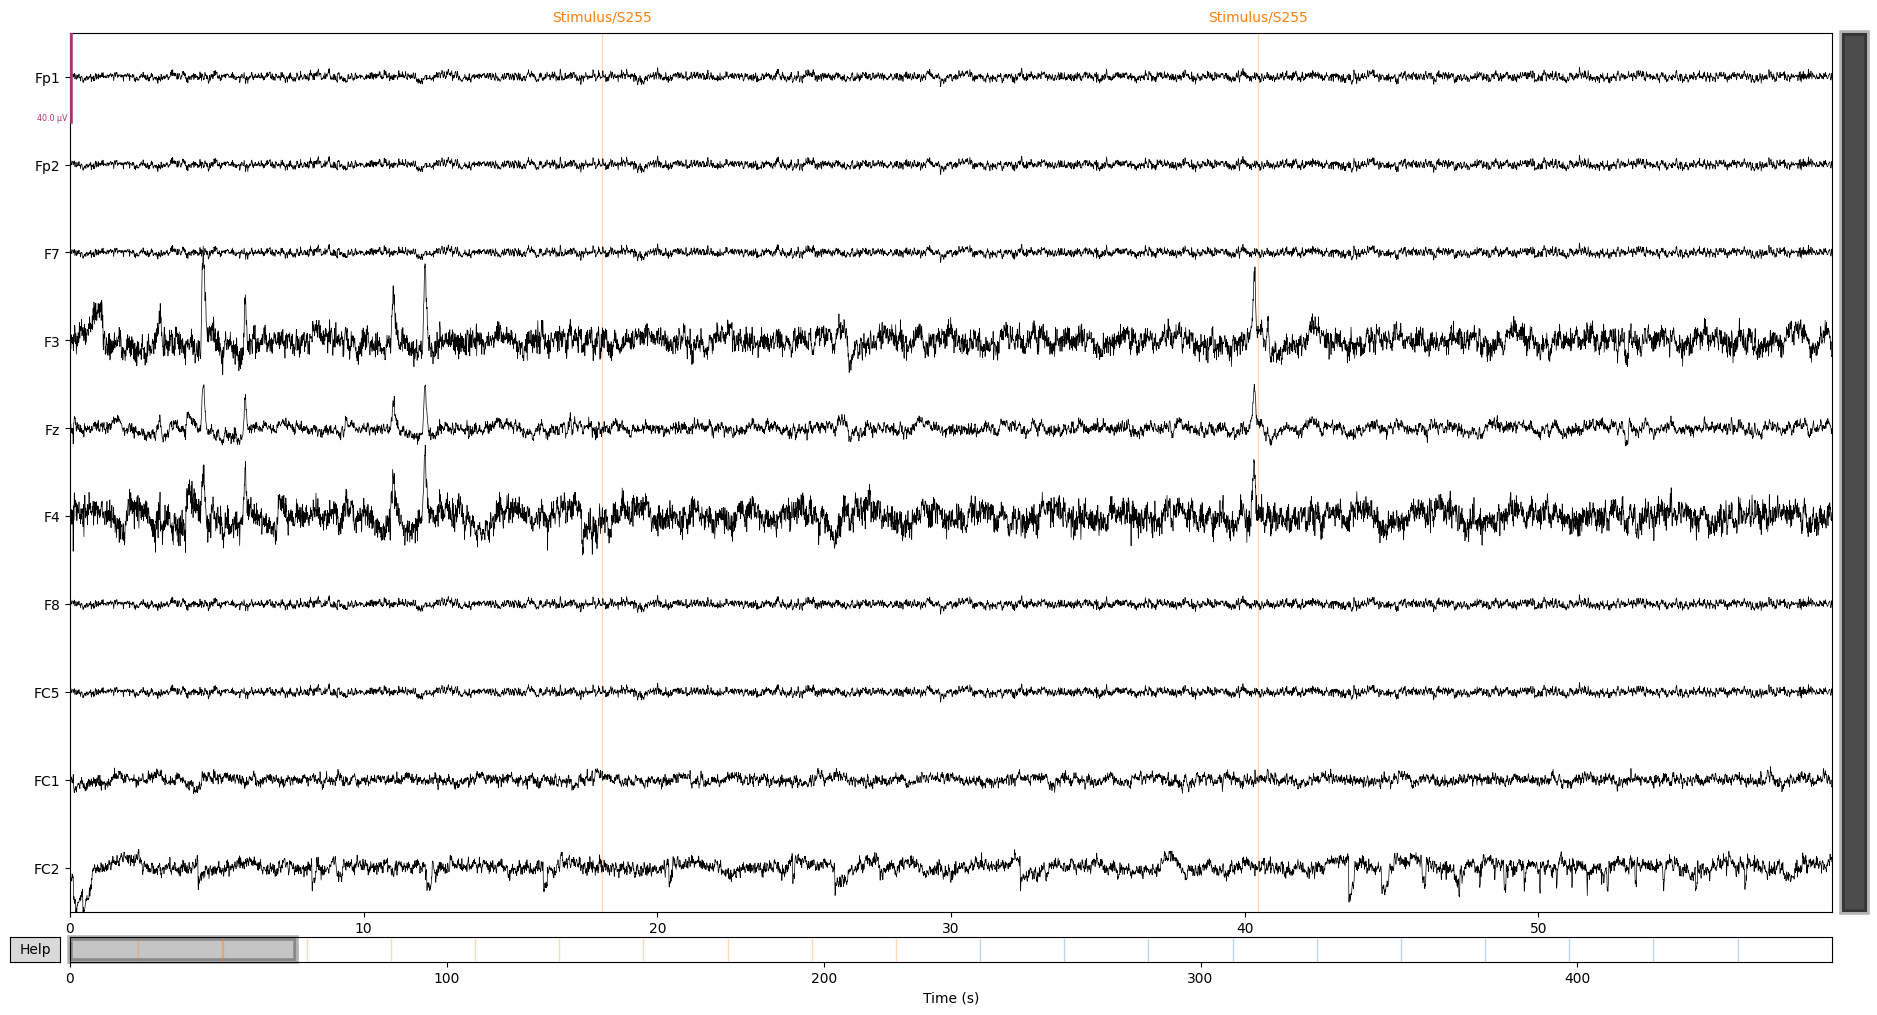

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


/home/olebi/projects/iBOTS-Intro-to-EEG-MEG-Analysis-with-MNE-Python/.pixi/envs/default/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


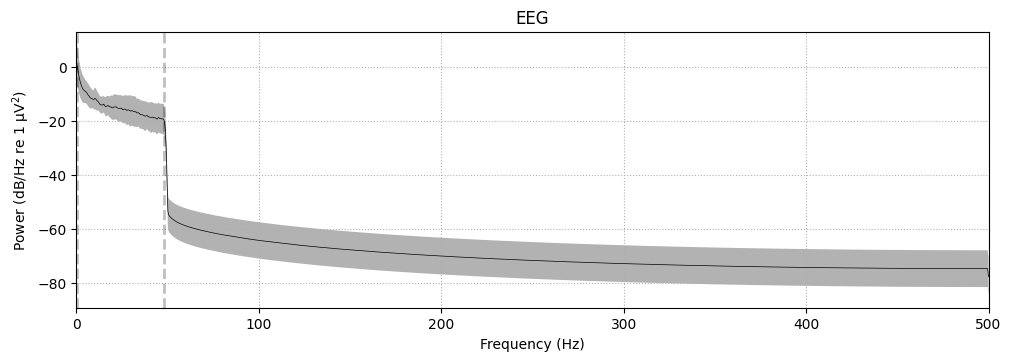

In [238]:
raw_filt = raw.copy()
raw_filt.filter(l_freq=0.3, h_freq=48, l_trans_bandwidth=0.1, h_trans_bandwidth=2)
raw_filt.plot(duration=60);
spectrum = raw_filt.compute_psd()
spectrum.plot(average=True);